In [39]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Modeling

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler








In [ ]:
from pmdarima import auto_arima

In [40]:
# Load all datasets
credit_owned = pd.read_csv('CREDIT_OWNED.csv')
personal_expenditure = pd.read_csv('PERSONAL_EXPENDITURE.csv')
saving_rate = pd.read_csv('SAVING_RATE.csv')
disposable_personal_income = pd.read_csv('DSPIC96.csv')
avg_hourly_earnings = pd.read_csv('CES0500000003.csv')
unemployment_rate = pd.read_csv('UNRATE.csv')
federal_funds = pd.read_csv('FEDFUNDS.csv')
food_cpi = pd.read_csv('CPIUFDSL.csv')
cpi = pd.read_csv('CPIAUCSL.csv')
energy_cpi = pd.read_csv('CUSR0000SACE.csv')
shelter_cpi = pd.read_csv('CUSR0000SAH1.csv')
cc_delinquency_rate = pd.read_csv('DRCCLACBS.csv')

# Additional data sources
umich_consumer_sentiment = pd.read_csv("UMCSENT.csv")
retail_food_sales = pd.read_csv("RRSFS.csv")



In [41]:
# List of all dataframes using main branch variable names
dfs = [
    personal_expenditure,
    saving_rate,
    credit_owned,              
    cpi,
    cc_delinquency_rate,       
    unemployment_rate,
    federal_funds,             
    disposable_personal_income,
    umich_consumer_sentiment,
    retail_food_sales
]

# Convert observation_date to datetime for all
for df in dfs:
    df['observation_date'] = pd.to_datetime(df['observation_date'])

# Quick checks
personal_expenditure.info()
cpi.info()
retail_food_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  227 non-null    datetime64[ns]
 1   PCEC96            227 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.7 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  949 non-null    datetime64[ns]
 1   CPIAUCSL          948 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.0 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  408 no

In [42]:
# Merging all datasets into a master DataFrame using main branch variable names
master_df_eda = personal_expenditure \
    .merge(saving_rate, on='observation_date', how='left') \
    .merge(credit_owned, on='observation_date', how='left') \
    .merge(cpi, on='observation_date', how='left') \
    .merge(cc_delinquency_rate, on='observation_date', how='left') \
    .merge(unemployment_rate, on='observation_date', how='left') \
    .merge(federal_funds, on='observation_date', how='left') \
    .merge(disposable_personal_income, on='observation_date', how='left') \
    .merge(umich_consumer_sentiment, on='observation_date', how='left') \
    .merge(retail_food_sales, on='observation_date', how='left')

# Quick check of the structure
display(master_df_eda.info(), master_df_eda.head(), master_df_eda.tail())

# Save to CSV
master_df_eda.to_csv("master_dataframe_eda.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  227 non-null    datetime64[ns]
 1   PCEC96            227 non-null    float64       
 2   PSAVERT           227 non-null    float64       
 3   TOTALSL           227 non-null    float64       
 4   CPIAUCSL          226 non-null    float64       
 5   DRCCLACBS         76 non-null     float64       
 6   UNRATE            226 non-null    float64       
 7   FEDFUNDS          227 non-null    float64       
 8   DSPIC96           227 non-null    float64       
 9   UMCSENT           227 non-null    float64       
 10  RRSFS             226 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.6 KB


None

,observation_date,PCEC96,PSAVERT,TOTALSL,CPIAUCSL,DRCCLACBS,UNRATE,FEDFUNDS,DSPIC96,UMCSENT,RRSFS
0,2007-01-01,11181.0,2.4,2457945.58,203.437,3.98,4.6,5.25,11956.6,96.9,174891.0
1,2007-02-01,11178.2,2.8,2470049.92,204.226,NaN,4.5,5.26,11996.0,91.3,174584.0
2,2007-03-01,11190.7,3.0,2484433.18,205.288,NaN,4.4,5.26,12035.1,88.4,175078.0
3,2007-04-01,11201.5,3.0,2493729.77,205.904,4.02,4.5,5.25,12052.8,87.1,174140.0
4,2007-05-01,11218.0,2.8,2510016.06,206.755,NaN,4.4,5.25,12059.9,88.3,175611.0


,observation_date,PCEC96,PSAVERT,TOTALSL,CPIAUCSL,DRCCLACBS,UNRATE,FEDFUNDS,DSPIC96,UMCSENT,RRSFS
222,2025-07-01,16547.5,4.3,5057212.70,322.169,2.98,4.3,4.33,18009.5,61.7,225884.0
223,2025-08-01,16595.8,4.1,5059896.38,323.291,NaN,4.3,4.33,18027.6,58.2,226329.0
224,2025-09-01,16614.3,4.0,5071365.99,324.245,NaN,4.4,4.22,18037.9,55.1,225814.0
225,2025-10-01,16665.1,3.7,5080601.87,NaN,2.94,NaN,4.09,18014.8,53.6,NaN
226,2025-11-01,16715.4,3.5,5084831.24,325.063,NaN,4.5,3.88,18037.3,51.0,226136.0


In [43]:
# Interpolating missing values
master_df_eda.interpolate(method='linear', inplace=True)

# Quick check after interpolation
master_df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  227 non-null    datetime64[ns]
 1   PCEC96            227 non-null    float64       
 2   PSAVERT           227 non-null    float64       
 3   TOTALSL           227 non-null    float64       
 4   CPIAUCSL          227 non-null    float64       
 5   DRCCLACBS         227 non-null    float64       
 6   UNRATE            227 non-null    float64       
 7   FEDFUNDS          227 non-null    float64       
 8   DSPIC96           227 non-null    float64       
 9   UMCSENT           227 non-null    float64       
 10  RRSFS             227 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.6 KB


In [44]:
# Rename columns for clarity in your EDA master DataFrame
master_df_eda = master_df_eda.rename(columns={
    'PCEC96': 'consumer_spending(in_billions)',
    'PSAVERT': 'saving_rate(%)',
    'TOTALSL': 'consumer_credit(in_millions)',      
    'CPIAUCSL': 'CPI(Index)',
    'DRCCLACBS': 'delinquency_rate(%)',
    'UNRATE': 'unemployment_rate(%)',
    'FEDFUNDS': 'fed_funds_rate(%)',           
    'DSPIC96': 'real_disposable_income(in_billions)',
    'UMCSENT': 'consumer_sentiment(Index)',
    'RRSFS': 'retail_food_sales(in_Millions)'
})

# Quick check
master_df_eda.info()
master_df_eda.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   observation_date                     227 non-null    datetime64[ns]
 1   consumer_spending(in_billions)       227 non-null    float64       
 2   saving_rate(%)                       227 non-null    float64       
 3   consumer_credit(in_millions)         227 non-null    float64       
 4   CPI(Index)                           227 non-null    float64       
 5   delinquency_rate(%)                  227 non-null    float64       
 6   unemployment_rate(%)                 227 non-null    float64       
 7   fed_funds_rate(%)                    227 non-null    float64       
 8   real_disposable_income(in_billions)  227 non-null    float64       
 9   consumer_sentiment(Index)            227 non-null    float64       
 10  retail_food_sa

,observation_date,consumer_spending(in_billions),saving_rate(%),consumer_credit(in_millions),CPI(Index),delinquency_rate(%),unemployment_rate(%),fed_funds_rate(%),real_disposable_income(in_billions),consumer_sentiment(Index),retail_food_sales(in_Millions)
7,2007-08-01,11300.1,2.2,2552767.07,207.667,4.473333,4.6,5.02,12070.9,83.4,175125.0
172,2021-05-01,14771.4,10.0,4238937.19,268.383,1.570000,5.8,0.06,16922.4,82.9,225529.0
209,2024-06-01,16064.4,5.7,5027254.09,313.044,3.206667,4.1,5.33,17751.1,68.2,221199.0
156,2020-01-01,14230.7,6.8,4171798.04,259.127,2.690000,3.6,1.55,15842.8,99.8,198790.0
75,2013-04-01,11826.4,5.1,2972772.62,231.797,2.530000,7.6,0.15,12893.4,76.4,174390.0


In [45]:
# After 2008 Crisis
start_date = '2010-01-01' 
covid_start = '2020-03-01'
covid_end = '2023-07-01'

# Cut out all data before start_date
master_df_eda = master_df_eda[master_df_eda['observation_date'] >= pd.Timestamp(start_date)]

# Set observation_date as index
master_df_eda = master_df_eda.set_index('observation_date')

# Set era for each row
def era_group(date):
    if date < pd.Timestamp(covid_start):
        return 'Pre-COVID'
    elif date < pd.Timestamp(covid_end):
        return 'COVID/Inflation Shock'
    else:
        return 'Post-Shock'
        
master_df_eda['era'] = master_df_eda.index.map(era_group)

# Color map for eras
ERA_COLORS = {
    'Pre-COVID': '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock': '#4CAF50'
}

print(master_df_eda['era'].value_counts())

era
Pre-COVID                122
COVID/Inflation Shock     40
Post-Shock                29
Name: count, dtype: int64


In [46]:
# Plot with colored era
COVID_START = pd.Timestamp('2020-03-01')    # WHO pandemic declaration
RATE_HIKE_START = pd.Timestamp('2022-03-01') # First Fed rate hike
INFLATION_PEAK = pd.Timestamp('2022-06-01') # CPI-U peak at 9.1% YoY

# Stimulus check dates
STIMULUS1 = pd.Timestamp('2020-04-15')   
STIMULUS2 = pd.Timestamp('2021-01-04')   
STIMULUS3 = pd.Timestamp('2021-03-15')   

def plot_with_era(series, title, ylabel, ax=None,
                  show_covid=False,
                  show_rate_hike=False,
                  show_inflation_peak=False,
                  show_stimulus=False):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
    
    # Era shading
    ax.axvspan(master_df_eda.index.min(), pd.Timestamp('2020-02-01'),
               alpha=0.08, color=ERA_COLORS['Pre-COVID'], label='Pre-COVID')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
               alpha=0.08, color=ERA_COLORS['COVID/Inflation Shock'], label='COVID/Inflation')
    ax.axvspan(pd.Timestamp('2023-07-01'), master_df_eda.index.max(),
               alpha=0.08, color=ERA_COLORS['Post-Shock'], label='Post-Shock')
    
    # Optional key event lines
    if show_rate_hike:
        ax.axvline(RATE_HIKE_START, color='purple', ls='--', lw=1, alpha=0.7, label='Rate Hike Start')
    if show_inflation_peak:
        ax.axvline(INFLATION_PEAK, color='orange', ls='--', lw=1, alpha=0.7, label='Inflation Peak')
    if show_stimulus:
        ax.axvline(STIMULUS1, color='blue', ls='--', lw=1, alpha=0.7, label='Stimulus 1')
        ax.axvline(STIMULUS2, color='cyan', ls='--', lw=1, alpha=0.7, label='Stimulus 2')
        ax.axvline(STIMULUS3, color='navy', ls='--', lw=1, alpha=0.7, label='Stimulus 3')
    
    # Data
    data = series.dropna()
    ax.plot(data.index, data.values, color='#333333', lw=1.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    return ax

<Axes: title={'center': 'Real Disposable Income'}, ylabel='Billions'>

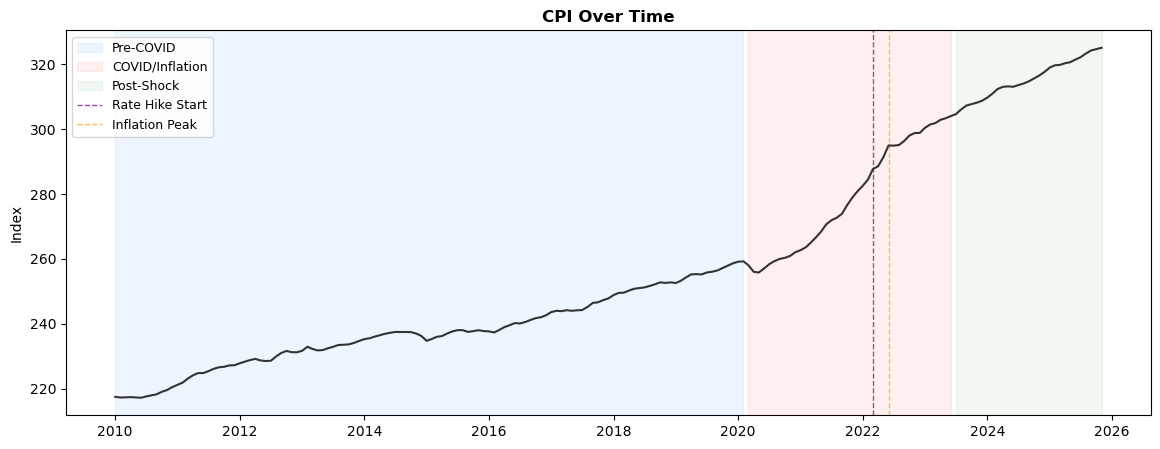

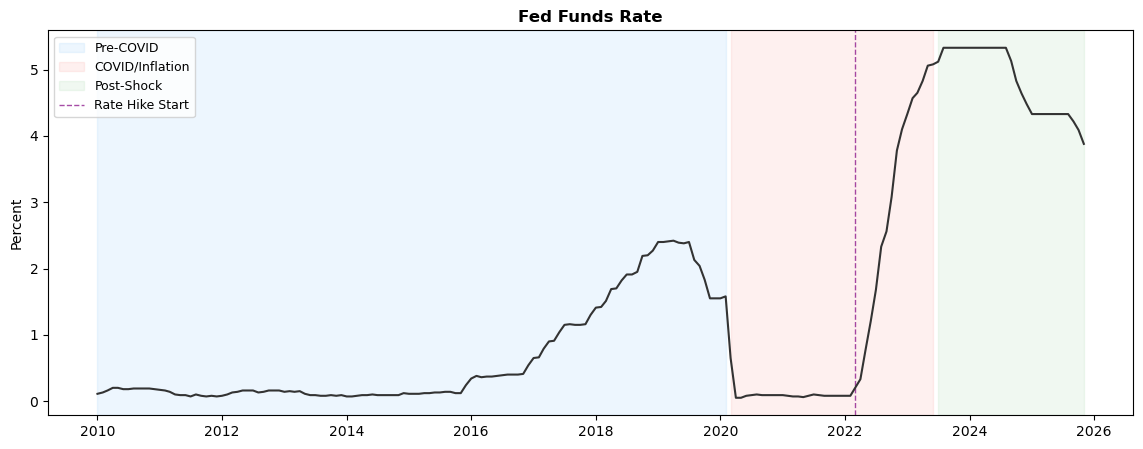

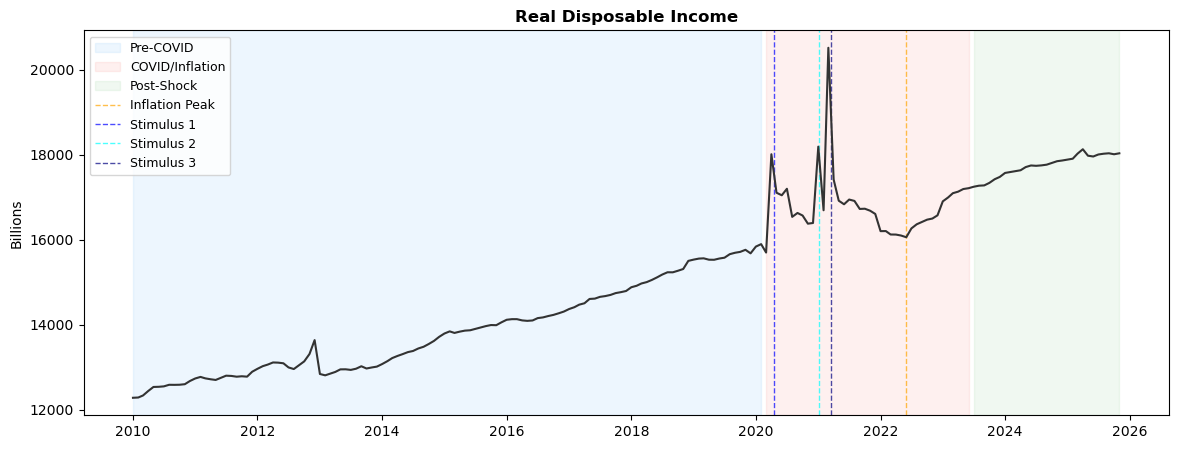

In [47]:
# Label series from master_df_eda columns
cpi_series = master_df_eda['CPI(Index)']
fed_series = master_df_eda['fed_funds_rate(%)']
rdi_series = master_df_eda['real_disposable_income(in_billions)']

# Step 1: Inflation Trends
plot_with_era(cpi_series,
              "CPI Over Time",
              "Index",
              show_covid=True,
              show_rate_hike=True,
              show_inflation_peak=True)

plot_with_era(fed_series,
              "Fed Funds Rate",
              "Percent",
              show_rate_hike=True)

plot_with_era(rdi_series,
              "Real Disposable Income",
              "Billions",
              show_covid=True,
              show_inflation_peak=True,
              show_stimulus=True)

In [48]:
# Era summary function
def era_summary(variable):
    summary = master_df_eda.groupby('era', observed=True)[variable] \
                       .agg(['mean','min','max','first','last'])

    summary = summary.reindex(['Pre-COVID', 
                               'COVID/Inflation Shock', 
                               'Post-Shock'])

    pct_change = summary['mean'].pct_change() * 100

    print(f"\n{variable} Summary by Era:\n", summary)
    print(f"\n{variable} Mean % Change Across Eras:\n", pct_change)

    return summary, pct_change

# Example usage
cpi_summary, cpi_pct = era_summary('CPI(Index)')
fed_summary, fed_pct = era_summary('fed_funds_rate(%)')
rdi_summary, rdi_pct = era_summary('real_disposable_income(in_billions)')


CPI(Index) Summary by Era:
                              mean      min      max    first     last
era                                                                  
Pre-COVID              237.475115  217.199  259.250  217.488  259.250
COVID/Inflation Shock  279.124350  255.802  304.014  258.076  304.014
Post-Shock             315.418414  304.609  325.063  304.609  325.063

CPI(Index) Mean % Change Across Eras:
 era
Pre-COVID                      NaN
COVID/Inflation Shock    17.538358
Post-Shock               13.002830
Name: mean, dtype: float64

fed_funds_rate(%) Summary by Era:
                            mean   min   max  first  last
era                                                     
Pre-COVID              0.628852  0.07  2.42   0.11  1.58
COVID/Inflation Shock  1.276500  0.05  5.08   0.65  5.08
Post-Shock             4.838621  3.88  5.33   5.12  3.88

fed_funds_rate(%) Mean % Change Across Eras:
 era
Pre-COVID                       NaN
COVID/Inflation Shock    102.988790
P

## Step 1: Inflation Shock Context- How Prices and Policy Shifted
**CPI Over Time: The Inflation Story**
* Pre-COVID average: 237.5
* COVID/Inflation Shock average: 279.1 (+17.5%)
* Post-Shock average: 315.4 (+13% from shock, +32.8% overall)

**Fed Funds Rate: The Policy Response**
* Pre-COVID average: 0.63% (basically zero)
* COVID/Inflation Shock average: 1.28% (+103%)
* Post-Shock average: 4.84% (+279% from shock, +668% overall!)
* Peak rate: 5.33%

`The rate hike start line (March 2022) align with the steep upward slope from near-zero to 5%+.`

**Real Disposable Income (RDI): Purchasing Power Under Pressure**
* Pre-COVID average: $13,852B
* COVID/Inflation Shock average: $16,821B (+21.4%)
* Post-Shock average: $17,751B (+5.5% from shock)
* Spike: Feb 2020 $15,702B → Mar 2021 $20,520B (+30.7% in 13 months)

`The stimulus event lines (April 2020, Jan 2021, March 2021) explain the mountain-shaped spike in RDI.`

### What Changed and Why It Matters

| Period | CPI Change (Avg) | Fed Funds Change | RDI Change | What It Reveals |
|--------|-----------------|-----------------|------------|----------------|
| Pre-COVID → Shock | +17.5% | +103% (0.63% → 1.28%) | +21.4% | Inflation took off, rates started climbing, and stimulus temporarily boosted incomes. |
| Shock → Post-Shock | +13.0% | +279% (1.28% → 4.84%) | +5.5% | Inflation kept rising, rates skyrocketed, but the temporary boost from stimulus ended. |
---
### Period-by-Period Breakdown

| Metric | Pre-COVID Avg | Post-Shock Avg | Change | What It Tells Us |
|--------|---------------|----------------|--------|-----------------|
| CPI (Inflation) | 237.5 | 315.4 | +32.8% | Prices didn’t just spike temporarily—they settled at a permanently higher level. The post-shock economy runs on a new price baseline. |
| Fed Funds Rate | 0.63% | 4.84% | +669% | The era of cheap money is over. Borrowing costs are structurally higher, signaling a permanent shift in monetary policy. |
| Real Disposable Income | $13,852B | $17,751B | +28.1% | Appears strong at first glance, but the temporary stimulus boost masks underlying stagnation in income growth. |


### The Pattern
1) **Prices are permanently higher**
Inflation didn't spike and return to normal, it jumped 17.5% during the shock, then another 13% post-shock. From 237.5 pre-COVID to 315.4 now, prices have structurally shifted upward.
    

2) **Borrowing costs have completely reset**
    The Fed funds rate averaged 0.63% for years. Now it’s 4.84%. This isn’t a short-term blip—it’s a new normal. Households face borrowing costs roughly 8x higher than before.

3) **Income growth was a mirage**
    Real disposable income surged 21.4% during the shock, but that spike came from stimulus, not underlying growth. Post-shock, income growth slowed to just 5.5%. The $20.5T lift in March 2021 reflected government support, not raises. When stimulus ended, so did the boost.

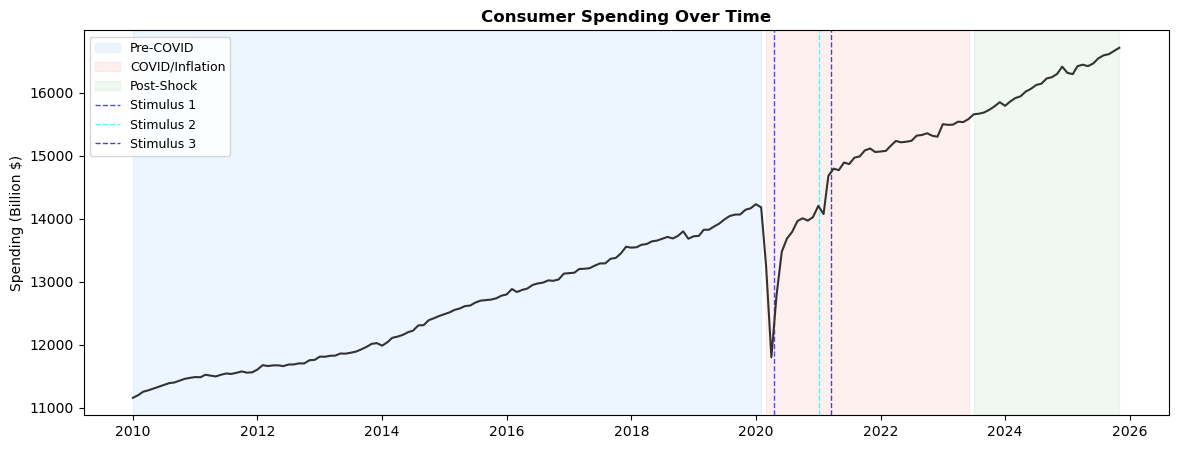

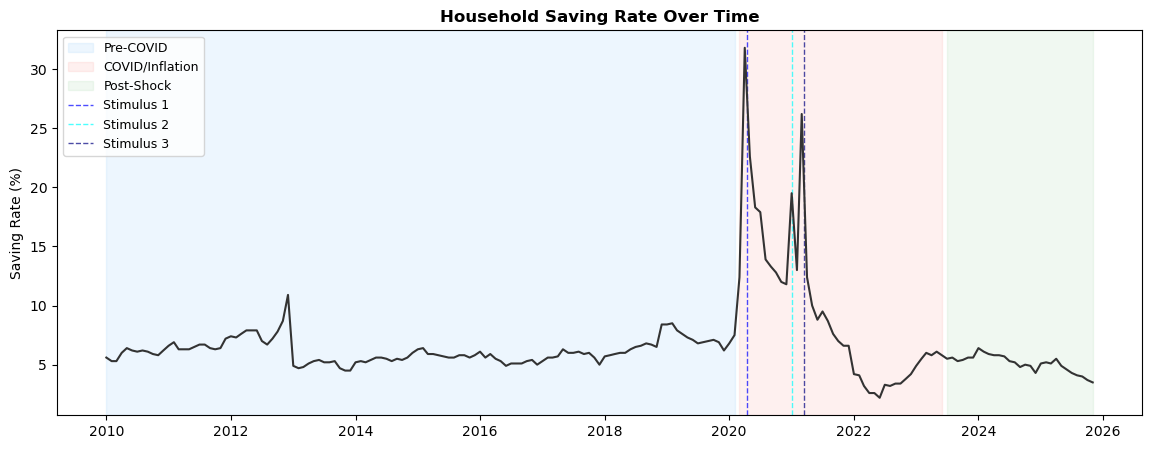

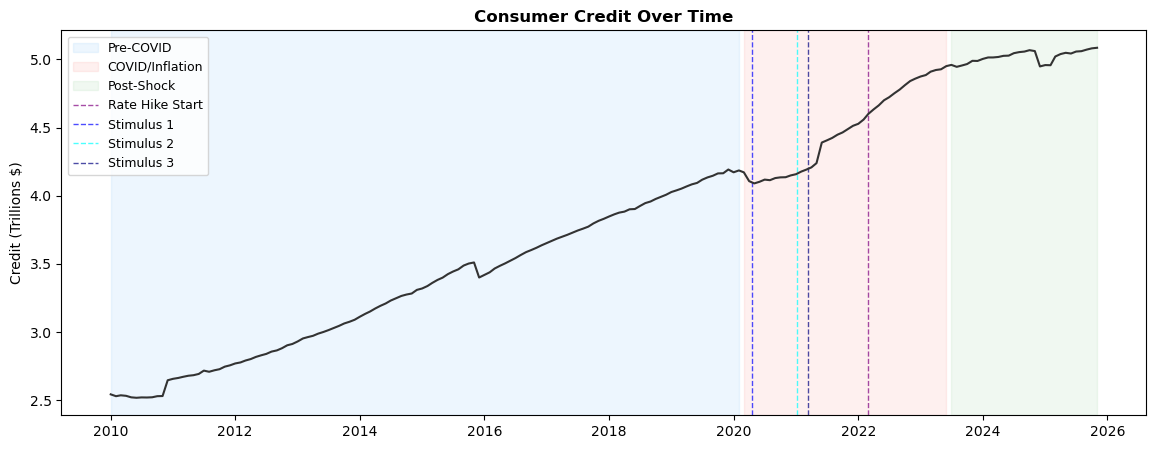

In [50]:
# Consumer Spending
plot_with_era(master_df_eda['consumer_spending(in_billions)'], 
              'Consumer Spending Over Time', 
              'Spending (Billion $)',
              show_stimulus=True)
plt.show()

# Household Saving Rate
plot_with_era(master_df_eda['saving_rate(%)'], 
              'Household Saving Rate Over Time', 
              'Saving Rate (%)',
              show_stimulus=True)
plt.show()

# Consumer Credit
ax = plot_with_era(master_df_eda['consumer_credit(in_millions)'], 
                   'Consumer Credit Over Time', 
                   'Credit (Trillions $)',
                   show_stimulus=True,
                   show_rate_hike=True)

# Convert axis to trillions
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))
plt.show()

In [51]:
# Era Summary for Consumer Spending, Saving Rate, and Consumer Credit
spending_summary, spending_pct = era_summary('consumer_spending(in_billions)')
saving_summary, saving_pct = era_summary('saving_rate(%)')
credit_summary, credit_pct = era_summary('consumer_credit(in_millions)')


consumer_spending(in_billions) Summary by Era:
                                mean      min      max    first     last
era                                                                    
Pre-COVID              12542.528689  11156.8  14230.7  11156.8  14181.4
COVID/Inflation Shock  14706.240000  11798.6  15584.1  13249.1  15584.1
Post-Shock             16171.010345  15658.4  16715.4  15658.4  16715.4

consumer_spending(in_billions) Mean % Change Across Eras:
 era
Pre-COVID                      NaN
COVID/Inflation Shock    17.250998
Post-Shock                9.960196
Name: mean, dtype: float64

saving_rate(%) Summary by Era:
                            mean  min   max  first  last
era                                                    
Pre-COVID              6.163934  4.5  10.9    5.6   7.5
COVID/Inflation Shock  9.425000  2.2  31.8   12.4   5.8
Post-Shock             5.110345  3.5   6.4    5.5   3.5

saving_rate(%) Mean % Change Across Eras:
 era
Pre-COVID                      NaN

## Step 2: Core Consumer Behaviors- Spending, Savings, and Debt Patterns
**Consumer Spending Over Time**
* Pre-COVID average: $12,543 billion
* COVID/Inflation Shock average: $14,706 billion (+17.2% from pre-COVID)
* Post-Shock average: $16,171 billion (+9.96% from shock, +28.9% overall from pre-COVID)
* Growth rate: Dropped from +17.2% (pre→shock) to +9.96% (shock→post)

**Household Savings Rate Over Time**
* Pre-COVID average: 6.16%
* COVID/Inflation Shock average: 9.43% (+53% increase!)
* Post-Shock average: 5.11% (-45.8% from shock, -17.0% from pre-COVID)
* The spike: From ~7% pre-COVID to 31.8% peak during shock (stimulus/lockdowns)
* Current: Down to 3.5% (lower than any point in pre-COVID era)

**Consumer Credit Over Time**
* Pre-COVID average: $3.32 trillion
* COVID/Inflation Shock average: $4.48 trillion (+35.0% increase!)
* Post-Shock average: $5.02 trillion (+12.0% from shock, +51.2% overall from pre-COVID)
* Growth rate: Decelerated from +35.0% (pre→shock) to +12.0% (shock→post)
* Current: $5.08 trillion (all-time high)

### What Changed and Why It Matters
| Period | Time Span | Credit Growth | Annualized Rate | What It Reveals |
|--------|-----------|--------------|----------------|-----------------|
| Pre-COVID (2010–2020) | 10 years | $2.5T → $4.1T | ~5.1% per year | Steady, "normal" debt accumulation during economic expansion. |
| Shock (2020–2023) | 3 years | $4.1T → $4.95T | ~6.5% per year | Accelerated borrowing as households adjusted to stimulus withdrawal and rising inflation. |
| Post-Shock (2023–2026) | 3 years | $4.95T → $5.08T | ~0.9% per year | Sharp deceleration in credit growth, suggesting tighter conditions or reduced borrowing capacity. |

--- 
### Period-by-Period Breakdown
| Metric          | Pre-COVID | Post-Shock | Change | Interpretation                      |
| --------------- | --------- | ---------- | ------ | ----------------------------------- |
| Spending        | $12.54T   | $16.17T    | +28.9% | Nominal growth; real growth minimal |
| Saving Rate     | 6.16%     | 5.11%      | -17.0% | Permanent decline in savings        |
| Consumer Credit | $3.32T    | $5.02T     | +51.2% | Permanent debt elevation            |

### The Pattern
1) **Spending has increased, but real growth is limited**  
Nominal consumer spending rose 28.9% from pre-COVID to post-shock, yet inflation has eroded much of this gain. In real terms, households are spending more money but buying less value.

2) **The savings buffer has mostly disappeared**  
Savings spiked to 31.8% during the shock thanks to stimulus, but post-shock they dropped to 5.11%, below pre-COVID levels. Currently at 3.5%, households have far less financial flexibility than before.

3) **Debt is higher, but new borrowing is slowing sharply**  
Total consumer debt is up 51% from pre-COVID. Borrowing accelerated to ~6.5% annually during the shock but has fallen to 0.9% post-shock, indicating households are approaching their borrowing limits.

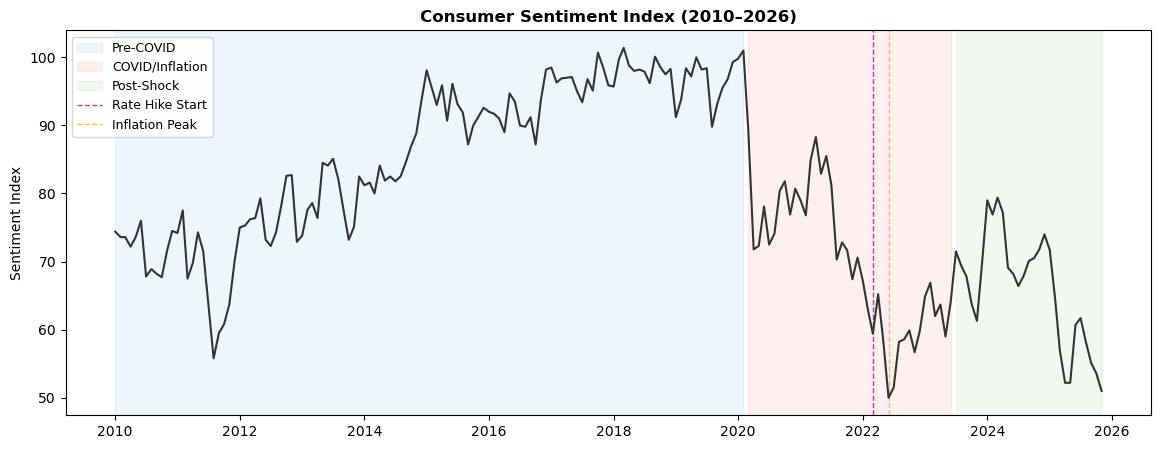

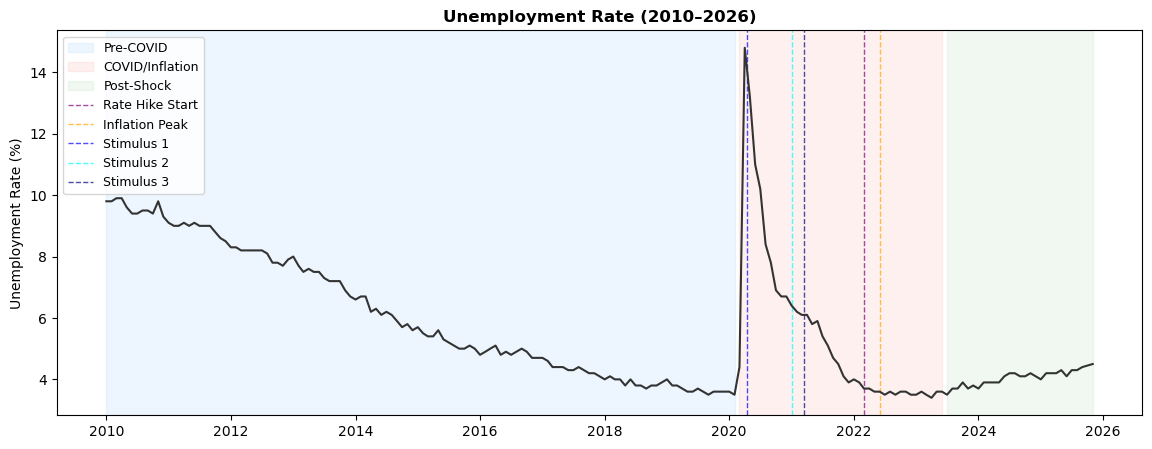

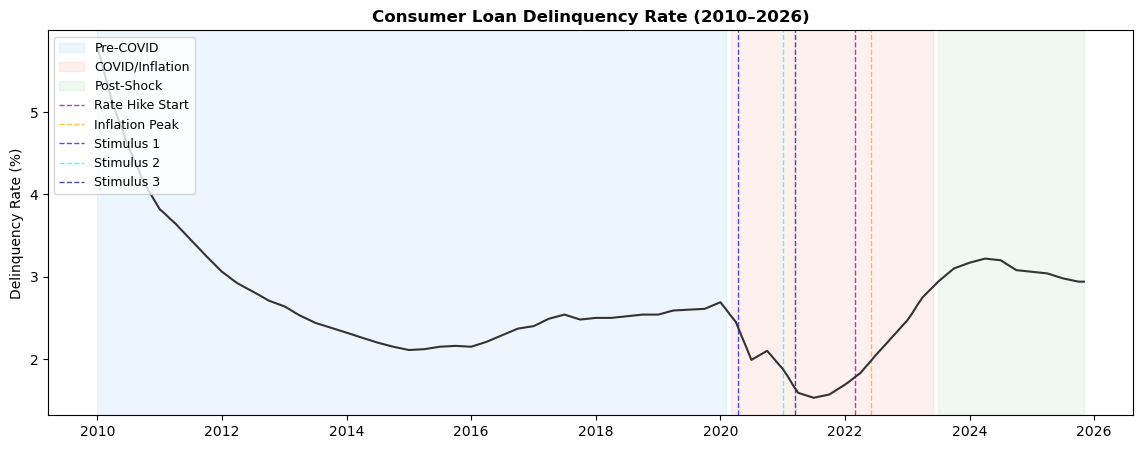

In [52]:
# Step 3: Influencers / Explanatory Variables

plot_with_era(
    master_df_eda['consumer_sentiment(Index)'],
    'Consumer Sentiment Index (2010–2026)',
    'Sentiment Index',
    show_rate_hike=True,
    show_inflation_peak=True
)
plt.show()

plot_with_era(
    master_df_eda['unemployment_rate(%)'],
    'Unemployment Rate (2010–2026)',
    'Unemployment Rate (%)',
    show_stimulus=True,
    show_rate_hike=True,
    show_inflation_peak=True
)
plt.show()

plot_with_era(
    master_df_eda['delinquency_rate(%)'],
    'Consumer Loan Delinquency Rate (2010–2026)',
    'Delinquency Rate (%)',
    show_stimulus=True,
    show_rate_hike=True,
    show_inflation_peak=True
)
plt.show()

In [53]:
# Era summaries for explanatory variables
sentiment_summary, sentiment_pct = era_summary('consumer_sentiment(Index)')
unemployment_summary, unemployment_pct = era_summary('unemployment_rate(%)')
delinquency_summary, delinquency_pct = era_summary('delinquency_rate(%)')


consumer_sentiment(Index) Summary by Era:
                             mean   min    max  first   last
era                                                        
Pre-COVID              85.740984  55.8  101.4   74.4  101.0
COVID/Inflation Shock  69.937500  50.0   89.1   89.1   64.2
Post-Shock             65.934483  51.0   79.4   71.5   51.0

consumer_sentiment(Index) Mean % Change Across Eras:
 era
Pre-COVID                      NaN
COVID/Inflation Shock   -18.431657
Post-Shock               -5.723707
Name: mean, dtype: float64

unemployment_rate(%) Summary by Era:
                            mean  min   max  first  last
era                                                    
Pre-COVID              6.177049  3.5   9.9    9.8   3.5
COVID/Inflation Shock  5.482500  3.4  14.8    4.4   3.6
Post-Shock             4.053448  3.5   4.5    3.5   4.5

unemployment_rate(%) Mean % Change Across Eras:
 era
Pre-COVID                      NaN
COVID/Inflation Shock   -11.244029
Post-Shock            

## Step 3: Influencers & Explantory Variables- Indicators of Financial Stress
**Consumers Sentiment Over Time**
* Pre-COVID average: 85.7
* COVID/Inflation Shock average: 69.9 (-18.4%)
* Post-Shock average: 65.9 (-5.7% from shock, -23.1% overall from pre-COVID)
* Current: 51.0 (approaching pandemic lows!)

**Unemployment Rate Over Time** 
* Pre-COVID average: 6.18% (includes post-GFC recovery)
* COVID/Inflation Shock average: 5.48% (-11.2%)
* Post-Shock average: 4.05% (-26.1% from shock, -34.5% overall from pre-COVID)
* Shock peak: 14.8% (April 2020) → Current: 4.5%

**Delinquency Rate Over Time**
* Pre-COVID average: 2.77%
* COVID/Inflation Shock average: 2.04% (-26.5% — stimulus helped people pay bills!)
* Post-Shock average: 3.08% (+51.0% from shock!)
* Current: 2.94% and rising

## What Changed and Why It Matters

| Metric             | Pre-COVID Avg | Post-Shock Avg | Change  | Period Analysis                           | What It Really Tells Us                                                                 |
|-------------------|---------------|----------------|---------|------------------------------------------|-----------------------------------------------------------------------------------------|
| Consumer Sentiment | 85.7          | 65.9           | -23.1%  | Shock: -18.4% ↓ <br> Post-Shock: -5.7% ↓ | Confidence dropped during the shock and hasn’t bounced back. Americans have adjusted to a more cautious, lower-expectation view of the economy. |
| Unemployment Rate  | 6.18%         | 4.05%          | -34.5%  | Shock: -11.2% ↓ (then spike to 14.8%) <br> Post-Shock: -26.1% ↓ | obs are plentiful, but that hasn’t lifted people’s outlook. Low unemployment hasn’t offset rising costs, people feel the squeeze even while working. |
| Delinquency Rate   | 2.77%         | 3.08%          | +51.0%  | Shock: -26.5% ↓ (stimulus masked stress) <br> Post-Shock: +51.0% ↑ | Stimulus temporarily kept bills paid, but that relief didn’t last. Post-shock, financial stress is back, and households are starting to miss payments. |

---

## Period-by-Period Breakdown

| Metric       | Pre-COVID → Shock         | What Happened                                               | Shock → Post-Shock       | What Happened                                           |
|-------------|---------------------------|-------------------------------------------------------------|--------------------------|---------------------------------------------------------|
| Sentiment   | 85.7 → 69.9 (-18.4%)     | COVID crashed confidence, but stimulus provided temporary floor | 69.9 → 65.9 (-5.7%)     | Confidence didn’t bounce back, people remained cautious even as conditions improved. |
| Unemployment| 6.18% → 5.48% (-11.2%)   | Massive spike (14.8%), then rapid recovery                 | 5.48% → 4.05% (-26.1%)  | Unemployment hit historic lows, but wages and purchasing power lagged behind inflation  |
| Delinquency | 2.77% → 2.04% (-26.5%)   | Stimulus and forbearance artificially suppressed missed payments | 2.04% → 3.08% (+51.0%)  | Financial stress resurfaced once stimulus ended, and missed payments increased significantly |


## The Pattern

1. **Spending is slowing down**  
   Consumer sentiment took a big hit, down 18.4% during the shock and another 5.7% afterward. Pre-COVID it was 85.7, now it's 65.9. Americans haven’t bounced back; they’ve settled into a more cautious, pessimistic mindset.

2. **Low unemployment doesn’t equal relief**  
   Unemployment is actually lower than before COVID (4.05% vs 6.18%), but sentiment is worse. This shows it’s not about job loss, it’s about inflation. People have work, but their dollars don’t stretch as far.

3. **Households are feeling the strain again**  
   Delinquencies dropped during the shock thanks to stimulus, but post-shock they’ve jumped 51%. Savings are gone, debt is high, and now households are starting to miss payments.

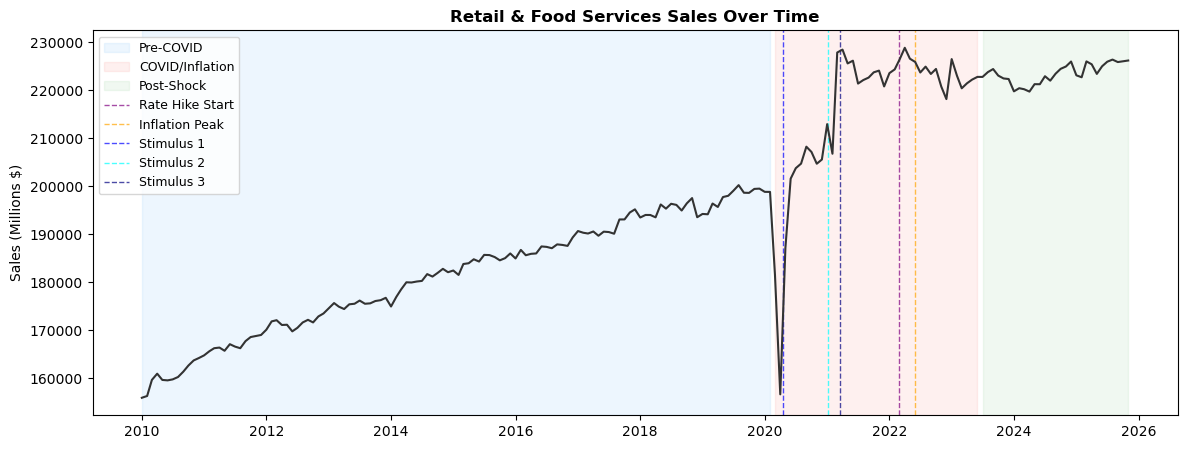

In [54]:
# Step 4: Retail & Food Sales
ax = plot_with_era(
    master_df_eda['retail_food_sales(in_Millions)'],
    'Retail & Food Services Sales Over Time',
    'Sales (Millions $)',
    show_stimulus=True,     
    show_rate_hike=True,     
    show_inflation_peak=True 
)
plt.show()

In [55]:
# Era summaries for Retail & Food Sales
retail_food_summary, retail_food_pct = era_summary('retail_food_sales(in_Millions)')


retail_food_sales(in_Millions) Summary by Era:
                                 mean       min       max     first      last
era                                                                         
Pre-COVID              181268.040984  155913.0  200191.0  155913.0  198777.0
COVID/Inflation Shock  216218.325000  156632.0  228788.0  181467.0  222726.0
Post-Shock             223435.655172  219665.0  226329.0  222720.0  226136.0

retail_food_sales(in_Millions) Mean % Change Across Eras:
 era
Pre-COVID                      NaN
COVID/Inflation Shock    19.280996
Post-Shock                3.337983
Name: mean, dtype: float64


## Step 4: Retail Lens-Confirming the Pattern

### Retail & Food Sales Over Time
- **Pre-COVID average:** $181,268 million  
- **COVID/Inflation Shock average:** $216,218 million (+19.3% from pre-COVID)  
- **Post-Shock average:** $223,436 million (+3.3% from shock, +23.3% overall from pre-COVID)  
- **The surge:** From $155.9B pre-COVID to $228.8B during shock—stimulus and pent-up demand  
- **Current:** Leveling off around $226B; growth clearly slowing  

### What Changed and Why It Matters

| Period | Retail Sales Growth | What It Reveals |
|--------|------------------|----------------|
| Pre-COVID → Shock | +19.3% | Stimulus checks and lockdown-driven stockpiling temporarily boosted retail and food spending |
| Shock → Post-Shock | +3.3% | Growth slowed sharply as stimulus faded and rising prices reduced consumers’ purchasing power |
---
### Period-by-Period Breakdown

| Metric | Pre-COVID Avg | Post-Shock Avg | Change | What It Tells Us |
|--------|---------------|----------------|--------|-----------------|
| Retail & Food Sales | $181.3B | $223.4B | +23.3% | Nominal growth looks good, but like consumer spending, real growth is minimal once you factor in inflation. |
---
### The Pattern
1) **Retail boomed during the shock—then stalled.**  
  Sales jumped nearly 20% during COVID as stimulus landed and people spent on goods. Post-shock, growth collapsed to just 3.3%—barely keeping up with population growth, let alone inflation.  

2) **Mirrors overall consumer spending trends.**  
  Step 2 showed spending growth slowing from 17.2% → 9.96%. Retail confirms it: the surge was temporary, the slowdown is real.  

3) **Food and essentials are eating up more of the budget.**  
  While total retail sales grew 23.3% overall, food-at-home prices rose even faster. Households are spending more on necessities and less on discretionary items.  

### Connecting Step 4 Back to Everything

| Step | What We Learned | How Retail Confirms It |
|------|----------------|----------------------|
| Step 1: Inflation | Prices up 32.8% permanently | Retail sales growth slowed to 3.3%, consumers can't keep spending like they did before|
| Step 2: Behaviors | Savings down, debt up, spending stretched | Retail surge was stimulus-fueled; post-shock stall shows households tapped out |
| Step 3: Stress | Sentiment crushed, delinquencies rising | Retail slowdown = consumers pulling back. They're feeling the pinch. |


### To Conclude

Retail and food sales are an early warning signal for household stress:  

- **During the shock:** Stimulus + pent-up demand = retail boom (+19.3%)  
- **Post-shock:** Stimulus gone + inflation high = retail stall (+3.3%)  

The 3.3% growth rate is barely enough to cover price increases. In real terms, retail spending is flat or falling. Households aren't buying more, they're just paying more for the same stuff.  

This isn't a temporary cooldown. It's what happens when:  

**Savings are drained** (Step 2: 6.16% → 5.11% → 3.5%)  
**Debt is maxed out** (Step 2: new borrowing 5.1% → 0.9%)  
**Sentiment is crushed** (Step 3: 85.7 → 65.9)  
**Delinquencies are rising** (Step 3: +51%)  

**Retail data reinforces the bigger picture: post-shock households are stretched to the limit**

In [ ]:
for df_ in [credit_owned,
    personal_expenditure,
    saving_rate,
    disposable_personal_income,
    avg_hourly_earnings,
    unemployment_rate,
    federal_funds,
    food_cpi,
    cpi,
    energy_cpi,
    shelter_cpi,
    cc_delinquency_rate,
    umich_consumer_sentiment, 
    retail_food_sales]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])
    df_.set_index("observation_date", inplace=True)
    df_.sort_index(inplace=True)



In [ ]:
personal_expenditure = personal_expenditure.rename(columns={"PCEC96": "consumer_spending"})
saving_rate = saving_rate.rename(columns={"PSAVERT": "saving_rate"})
credit_owned = credit_owned.rename(columns={"TOTALSL": "credit_total"})
df = personal_expenditure.join(saving_rate, how="inner").join(credit_owned, how="inner")
display(df.head)
print(personal_expenditure.columns)

In [ ]:
# df["t"] = np.arange(len(df))

# # month seasonality dummies (captures repeating annual patterns)
# df["month"] = df.index.month
# month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
# df = pd.concat([df.drop(columns=["month"]), month_dummies], axis=1)
# print(df)
# Key dates (for plots + splitting train/test)
covid_start = pd.Timestamp("2020-03-01")
inflation_start = pd.Timestamp("2021-03-01")


def plot_series(col, title=None):
    plt.figure(figsize=(11, 4))
    plt.plot(df.index, df[col])
    plt.axvline(covid_start, color="red")
    plt.axvline(inflation_start, color="orange")
    plt.title(title or col)
    plt.show()

# Levels
plot_series("consumer_spending", "Consumer Spending (Level)")
plot_series("saving_rate", "Saving Rate (Level, %)")
plot_series("credit_total", "Consumer Credit (Level)")

In [ ]:
train = df[df.index < covid_start].copy()
test  = df[df.index >= covid_start].copy()

# Create numeric time feature from dates (months since start)
start_date = df.index.min()
time_months_all = ((df.index.year - start_date.year) * 12 + (df.index.month - start_date.month)).to_numpy().reshape(-1, 1)
# print(time_months_all)
# # Same feature but for train only
time_months_train = time_months_all[df.index < covid_start]

# Fit model on pre-COVID spending trend
model = LinearRegression()
model.fit(time_months_train, train["consumer_spending"])
df["spending_pred"] = model.predict(time_months_all)

y_pred = df.loc[test.index, "spending_pred"] 

# Predict counterfactual for entire timeline

mse  = mean_squared_error(test["consumer_spending"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["consumer_spending"], y_pred)
r2   = r2_score(test["consumer_spending"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")
# Plot actual vs counterfactual
plt.figure(figsize=(11, 5))
plt.plot(df.index, df["consumer_spending"], label="Actual")
plt.plot(df.index, df["spending_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Spending: Actual vs Counterfactual (No t column)")
plt.show()

Consumer Spending (Real personal_expenditure = pd.read_csv('PERSONAL_EXPENDITURE.csv'))

To evaluate whether consumer spending changed after COVID and the inflation shock, a counterfactual linear regression model was trained using pre-2020 data to estimate the expected spending trajectory. When this model was applied to the post-2020 period, it produced a very low coefficient of determination (R² ≈ 0.018), meaning that the historical trend explains only about 1.8% of the variation in post-COVID spending. In addition, the prediction errors were relatively large (RMSE ≈ 981 and MAE ≈ 898), indicating that the model’s forecasts deviated substantially from actual observed spending. These metrics show that post-COVID spending no longer follows its historical trajectory, suggesting a structural change in consumption behavior. Although overall spending remained relatively strong, it behaved differently from what pre-pandemic trends would predict.

In [ ]:
saving_model = LinearRegression()
saving_model.fit(time_months_train, train["saving_rate"])

df["saving_pred"] = saving_model.predict(time_months_all)
y_pred = df.loc[test.index, "saving_pred"] 



mse  = mean_squared_error(test["saving_rate"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["saving_rate"], y_pred)
r2   = r2_score(test["saving_rate"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["saving_rate"], label="Actual")
plt.plot(df.index, df["saving_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Saving Rate: Actual vs Counterfactual")
plt.show()

Personal Saving Rate

The saving rate model reveals an even stronger structural break. A counterfactual model trained on pre-2020 data performs worse than a simple average prediction in the post-COVID period, as indicated by a negative R² value. A negative R² means that the historical trend fails to explain current behavior entirely. The model also produces sizable prediction errors (RMSE ≈ 5.84 and MAE ≈ 4.18), indicating that actual saving rates deviated meaningfully from expected values. This divergence reflects the unusual economic environment: saving_rate surged during the pandemic due to stimulus payments and limited spending opportunities, then fell sharply as inflation eroded purchasing power. The poor model performance confirms that saving behavior experienced a major structural shift.

In [ ]:

credit_model = LinearRegression()
credit_model.fit(time_months_train, train["credit_total"])

df["credit_pred"] = credit_model.predict(time_months_all)
y_pred = df.loc[test.index, "credit_pred"] 


mse  = mean_squared_error(test["credit_total"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["credit_total"], y_pred)
r2   = r2_score(test["credit_total"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["credit_total"], label="Actual")
plt.plot(df.index, df["credit_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Credit: Actual vs Counterfactual")
plt.show()


Consumer credit_ownedOutstanding

Consumer credit_ownedshows a different pattern compared to spending and saving. The counterfactual model trained on pre-COVID data achieves a moderate explanatory power (R² ≈ 0.338), meaning that about 33.8% of the variation in post-COVID credit_ownedlevels can still be explained by historical trends. While prediction errors exist (RMSE ≈ 284,831 and MAE ≈ 246,559), the model performs substantially better than in the spending and saving cases. This suggests that borrowing behavior continued along a partially predictable upward trajectory even after the inflation shock. The continued growth of credit, despite rising interest rates, implies that households increasingly relied on borrowing to maintain consumption as saving_rate declined.

Using a counterfactual model trained only on pre-March 2020 data, we compared observed post-inflation behavior to what would have been expected had historical trends continued unchanged. The results suggest a meaningful structural shift in household financial behavior. Real consumer spending recovered and remains modestly above its pre-COVID trend, indicating that aggregate consumption did not collapse permanently. However, the personal saving rate has remained significantly below its historical trajectory, suggesting households are saving structurally less than expected. At the same time, consumer credit_ownedlevels are persistently above their pre-2020 trend, indicating increased reliance on borrowing. Taken together, these patterns imply that while spending itself returned toward trend, the way households finance consumption has shifted—characterized by lower saving_rate buffers and higher credit_ownedusage—pointing to a lasting behavioral adjustment rather than a purely temporary disruption.

In [47]:
# cpi = pd.read_csv("CPIAUCSL.csv")
# federal_funds = pd.read_csv("FEDFUNDS.csv")
# disposable_personal_income = pd.read_csv("DSPIC96.csv")
# unemployment_rate = pd.read_csv("UNRATE.csv")
# cc_delinquency_rate = pd.read_csv("DRCCLACBS.csv")

In [48]:
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "inflation_index"
})

federal_funds = federal_funds.rename(columns={
    "observation_date": "date",
    "FEDFUNDS": "fed_funds_rate"
})

disposable_personal_income = disposable_personal_income.rename(columns={
    "observation_date": "date",
    "DSPIC96": "real_disposable_income"
})

unemployment_rate = unemployment_rate.rename(columns={
    "observation_date": "date",
    "UNRATE": "unemployment_rate"
})


food_cpi = food_cpi.rename(columns={
    "observation_date": "date",
    "CPIUFDSL": "food_cpi"
})

energy_cpi = energy_cpi.rename(columns={
    "observation_date": "date",
    "CUSR0000SACE": "energy_cpi"
})

shelter_cpi = shelter_cpi.rename(columns={
    "observation_date": "date",
    "CUSR0000SAH1": "shelter_cpi"
})

avg_hourly_earnings = avg_hourly_earnings.rename(columns={
    "observation_date": "date",
    "CES0500000003": "avg_hourly_earnings"
})

cc_delinquency_rate = cc_delinquency_rate.rename(columns={
    "observation_date": "date",
    "DRCCLACBS": "cc_delinquency_rate"
})

In [ ]:
# print(cpi)
df_behavior = df.copy()

df_merged = (
    personal_expenditure
    .join(saving_rate, how="inner")
    .join(credit_owned, how="inner")
    .join(cpi, how="inner")
    .join(federal_funds, how="inner")
    .join(disposable_personal_income, how="inner")
    .join(unemployment_rate, how="inner")
    .join(food_cpi, how="inner")
    .join(energy_cpi, how="inner")
    .join(shelter_cpi, how="inner")
    .join(avg_hourly_earnings, how="inner")
    .join(cc_delinquency_rate, how="inner")
)

print(df_merged.columns)
print(df_merged)

In [ ]:
print(df_merged.columns)

In [51]:
df_clean = df_merged.dropna()
X_spending = df_clean[[
    "inflation_index",
    "real_disposable_income",
    "unemployment_rate"
]]

y_spending = df_clean["consumer_spending"]

X_saving = df_clean[[
    "inflation_index",
    "real_disposable_income"
]]

y_saving = df_clean["saving_rate"]

X_credit_owned= df_clean[[
    "fed_funds_rate",
    "real_disposable_income"
]]

y_credit_owned= df_clean["credit_total"]

In [ ]:
spending_model = LinearRegression()
spending_model.fit(X_spending, y_spending)

saving_model = LinearRegression()
saving_model.fit(X_saving, y_saving)

credit_model = LinearRegression()
credit_model.fit(X_credit_owned, y_credit_owned)

In [ ]:
spending_coef = pd.Series(spending_model.coef_, index=X_spending.columns)
saving_coef = pd.Series(saving_model.coef_, index=X_saving.columns)
credit_coef = pd.Series(credit_model.coef_, index=X_credit_owned.columns)

print("Spending coefficients")
print(spending_coef)




The results suggest that consumer spending rises with higher inflation and higher disposable income but falls when unemployment increases. During the COVID period, inflation rose sharply while incomes were supported by stimulus and a strong labor market, which helped keep spending relatively high. At the same time, unemployment pressures tend to reduce spending, so changes in the labor market remain an important factor influencing consumer demand.

In [ ]:
print("\nSaving coefficients")
print(saving_coef)

These coefficients show how inflation and income relate to the personal saving rate. The negative coefficient for the inflation index (-0.21) suggests that when inflation increases, the saving rate tends to decrease. This likely reflects the post-COVID environment where rising prices forced households to spend more of their income on necessities, leaving less available to save. The coefficient for real disposable income (0.0039) is positive but very small, indicating that increases in income slightly raise the saving rate, though the effect is relatively weak compared to the impact of inflation. Overall, the model suggests that inflation plays a stronger role in shaping saving behavior than income changes during this period.

In [ ]:
print("\ncredit_owned coefficients")
print(credit_coef)

These coefficients indicate how borrowing behavior responds to interest rates and income. The large positive coefficient for the federal funds rate (46321.38) suggests that as interest rates rise, the level of consumer credit_ownedoutstanding also increases. This may reflect the post-COVID period when households continued borrowing despite higher rates, possibly due to higher living costs and inflationary pressure. The positive coefficient for real disposable income (398.44) shows that higher income is associated with slightly greater borrowing, as households with more income may feel more comfortable taking on credit. Overall, the model suggests that both rising interest rates and income are associated with higher consumer credit_ownedlevels during this period.

In [ ]:
print(df_clean.columns)

In [ ]:
# After 2008 Crisis
start_date = '2010-01-01' 
covid_start = '2020-03-01'
covid_end = '2023-07-01'

# Cut out all data before start_date
df_clean = df_clean[df_clean.index >= pd.Timestamp(start_date)]
if 'date' in df_clean.columns:
    df_clean = df_clean.set_index('date')

# Set era for each row
def era_group(date):
    """
    The function categorizes each date into pre-covid, covid/inflation shock, post-shock era
    """
    if date < pd.Timestamp(covid_start):
        return 'Pre-COVID'
    elif date < pd.Timestamp(covid_end):
        return 'COVID/Inflation Shock'
    else:
        return 'Post-Shock'
        
df_clean['era'] = df_clean.index.map(era_group)

# Color map for eras
ERA_COLORS = {
    'Pre-COVID': '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock': '#4CAF50'
}

print(df_clean['era'].value_counts())

In [58]:
#Plot with colored era
COVID_START = pd.Timestamp('2020-03-01')    # WHO pandemic declaration
INFLATION_PEAK = pd.Timestamp('2022-06-01') # CPI-U peak at 9.1% YoY
RATE_HIKE_START = pd.Timestamp('2022-03-01') # First Fed rate hike
def plot_with_era(series, title, ylabel, ax=None, show_trend=True):
    """Plot a time series with colored era shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
    
    # era shading
    ax.axvspan(df_clean.index.min(), pd.Timestamp('2020-02-01'),
               alpha=0.08, color=ERA_COLORS['Pre-COVID'], label='Pre-COVID')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
               alpha=0.08, color=ERA_COLORS['COVID/Inflation Shock'], label='COVID/Inflation')
    ax.axvspan(pd.Timestamp('2023-07-01'), df_clean.index.max(),
               alpha=0.08, color=ERA_COLORS['Post-Shock'], label='Post-Shock')
    
    # Key event lines
    ax.axvline(COVID_START, color='red', ls='--', lw=1, alpha=0.7)
    ax.axvline(INFLATION_PEAK, color='orange', ls='--', lw=1, alpha=0.7)
    ax.axvline(RATE_HIKE_START, color='purple', ls='--', lw=1, alpha=0.7)
    
    # Data
    data = series.dropna()
    ax.plot(data.index, data.values, color='#333333', lw=1.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    return ax

In [ ]:
print(df_clean.columns)

In [ ]:
#Plot Credit Owned, Saving Rate, Personal Expenditure
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

plot_with_era(df_clean['consumer_spending'], 
    'Real Personal Consumption Expenditures (Bn 2017$)', 'Bn 2017$', axes[0])

plot_with_era(df_clean['saving_rate'], 
    'Personal Saving Rate (%)', 'Percent', axes[1])

plot_with_era(df_clean['credit_total'] / 1e6, 
    'Consumer Credit Outstanding (Trillions $)', 'Tn $', axes[2])

plt.tight_layout()
plt.show()

In [ ]:
print(df_clean.columns)

In [62]:
# Calculate YoY and MoM change
df_clean['pe_yoy'] = df_clean['consumer_spending'].pct_change(12) * 100
df_clean['pe_mom'] = df_clean['consumer_spending'].pct_change(1) * 100
df_clean['credit_yoy'] = df_clean['credit_total'].pct_change(12) * 100
df_clean['credit_mom'] = df_clean['credit_total'].pct_change(1) * 100
df_clean['hourly_wage_yoy'] = df_clean['avg_hourly_earnings'].pct_change(12) * 100
df_clean['income_yoy'] = df_clean['real_disposable_income'].pct_change(12) * 100
df_clean['cpi_yoy'] = df_clean['inflation_index'].pct_change(12) * 100
df_clean['food_cpi_yoy'] = df_clean['food_cpi'].pct_change(12) * 100
df_clean['energy_cpi_yoy'] = df_clean['energy_cpi'].pct_change(12) * 100
df_clean['shelter_cpi_yoy'] = df_clean['shelter_cpi'].pct_change(12) * 100

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

plot_with_era(df_clean['pe_yoy'], 
    'Real PCE — Year-over-Year Growth Rate (%)', '% YoY', axes[0])
axes[0].axhline(0, color='black', lw=0.5)

plot_with_era(df_clean['credit_yoy'], 
    'Consumer Credit — Year-over-Year Growth Rate (%)', '% YoY', axes[1])
axes[1].axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
sr = df_clean['saving_rate'].dropna()

# Pre-COVID average
pre_covid_mean = sr.loc[:COVID_START].mean()
post_shock_mean = sr.loc['2023-07-01':].mean()

plot_with_era(sr, 'Personal Saving Rate — Is the New Normal Lower?', '%', ax)

ax.axhline(pre_covid_mean, color='blue', ls=':', lw=2, alpha=0.7, 
           label=f'Pre-COVID avg: {pre_covid_mean:.1f}%')
ax.axhline(post_shock_mean, color='green', ls=':', lw=2, alpha=0.7, 
           label=f'Post-Shock avg: {post_shock_mean:.1f}%')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [65]:
#Build the Model
START_DATE       = '2010-01-01'
COVID_START      = '2020-03-01'
COVID_END        = '2023-07-01'
TRAIN_END        = '2020-02-01'        # Last month of "normal" for training
SEASONAL_PERIOD  = 12                   # Monthly data

ERA_COLORS = {
    'Pre-COVID':             '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock':            '#4CAF50'
}

# The 3 core target series from the project brief
TARGETS = {
    'consumer_spending': {
        'label': 'Real Personal Consumption Expenditures',
        'unit':  'Bn 2017$'
    },
    'saving_rate': {
        'label': 'Personal Saving Rate',
        'unit':  '%'
    },
    'credit_total': {
        'label': 'Consumer Credit Outstanding',
        'unit':  'Mn $'
    }
}

# Exogenous features to feed into SARIMAX
EXOG_FEATURES = [
    'cpi', 'federal_funds', 'unemployment_rate',
    'disposable_personal_income', 'avg_hourly_earnings'
]

def build_counterfactual_model(df, target_col, exog_cols=None):
    train_mask = df_clean.index <= pd.Timestamp(TRAIN_END)
    post_mask  = df_clean.index > pd.Timestamp(TRAIN_END)

    y_train = df_clean.loc[train_mask, target_col].dropna()
    y_post  = df_clean.loc[post_mask, target_col].dropna()

    # Exogenous variables
    X_train, X_post = None, None
    if exog_cols:
        available_exog = [c for c in exog_cols if c in df_clean.columns and c != target_col]
        if available_exog:
            scaler = StandardScaler()
            X_all = df_clean[available_exog].interpolate(method='time').ffill().bfill()
            X_all[available_exog] = scaler.fit_transform(X_all[available_exog])

            X_train = X_all.loc[y_train.index]
            X_post  = X_all.loc[y_post.index]

    # Auto ARIMA
    print(f"Fitting auto_arima for: {target_col}")
    print(f"Training period: {y_train.index[0].strftime('%Y-%m')} → {y_train.index[-1].strftime('%Y-%m')}")
    print(f"Forecast period: {y_post.index[0].strftime('%Y-%m')} → {y_post.index[-1].strftime('%Y-%m')}")
    if X_train is not None:
        print(f"  Exogenous features: {available_exog}")

    auto_model = auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        stepwise=True,
        suppress_warnings=True,
        trace=False,
        error_action='ignore',
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        max_d=2, max_D=1,
        information_criterion='aic',
        n_fits=50
    )

    order = auto_model.order
    seasonal_order = auto_model.seasonal_order
    aic = auto_model.aic()

    print(f"Best order: ARIMA{order} x {seasonal_order}")
    print(f"AIC: {aic:.2f}")

    # Counterfactual forecast
    n_forecast = len(y_post)
    forecast, conf_int = auto_model.predict(
        n_periods=n_forecast,
        X=X_post,
        return_conf_int=True,
        alpha=0.05      # 95% CI
    )

    forecast_df = pd.DataFrame({
        'counterfactual':  forecast,
        'lower_ci':        conf_int[:, 0],
        'upper_ci':        conf_int[:, 1],
        'actual':          y_post.values
    }, index=y_post.index)

    # Gap = actual - counterfactual
    forecast_df['gap']     = forecast_df['actual'] - forecast_df['counterfactual']
    forecast_df['gap_pct'] = (forecast_df['gap'] / forecast_df['counterfactual']) * 100

    return {
        'model':          auto_model,
        'forecast_df':    forecast_df,
        'y_train':        y_train,
        'order':          order,
        'seasonal_order': seasonal_order,
        'aic':            aic,
        'exog_used':      available_exog if X_train is not None else []
    }

In [66]:
def run_all_models(df_clean):
    """Build counterfactual models for all 3 core targets."""
    print(" AUTO-SARIMAX COUNTERFACTUAL MODELING")

    models = {}
    for col in TARGETS:
        models[col] = build_counterfactual_model(
            df_clean, col, exog_cols=EXOG_FEATURES
        )
    return models

In [67]:
def gap_analysis(models, df_clean):
    """Compute summary statistics for actual vs counterfactual gaps."""
    print(" GAP ANALYSIS — ACTUAL vs COUNTERFACTUAL")

    for col, meta in TARGETS.items():
        fdf = models[col]['forecast_df']

        # Split gap into COVID era and post-shock era
        covid_gap = fdf.loc[
            (fdf.index >= pd.Timestamp(COVID_START)) &
            (fdf.index < pd.Timestamp(COVID_END)), 'gap_pct'
        ]
        post_gap = fdf.loc[
            fdf.index >= pd.Timestamp(COVID_END), 'gap_pct'
        ]

        print(f"\n  {meta['label']}  ({meta['unit']})")
        print(f"Model: ARIMA{models[col]['order']} x {models[col]['seasonal_order']}")
        print(f"AIC: {models[col]['aic']:.2f}")
        print(f"Exogenous: {models[col]['exog_used']}")
        print(f"COVID/Inflation period mean gap: {covid_gap.mean():+.2f}%")
        print(f"Post-Shock period mean gap:      {post_gap.mean():+.2f}%")
        print(f"Latest gap ({fdf.index[-1].strftime('%Y-%m')}):        {fdf['gap_pct'].iloc[-1]:+.2f}%")

        # Is the gap converging?
        if len(post_gap) >= 6:
            recent = post_gap.iloc[-6:].mean()
            earlier = post_gap.iloc[:6].mean()
            if abs(recent) < abs(earlier) * 0.5:
                print(f"Trend: GAP CONVERGING (temporary disruption)")
            elif abs(recent) > abs(earlier):
                print(f"Trend: GAP WIDENING (structural shift)")
            else:
                print(f"Trend: GAP PERSISTENT (possible structural change)")

In [68]:
def plot_counterfactual(models, df_clean, breaks_dict):
    """
    Create a 3-panel figure showing actual vs counterfactual
    for each core indicator, with structural breaks marked.
    """
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))
    fig.suptitle(
        'Has Inflation Permanently Changed Consumer Behaviour?\n'
        'Actual vs. Counterfactual (Pre-COVID SARIMAX Forecast)',
        fontsize=16, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        result = models[col]
        fdf = result['forecast_df']
        y_train = result['y_train']

        # Era shading
        ax.axvspan(df_clean.index.min(), pd.Timestamp('2020-02-01'),
                   alpha=0.06, color=ERA_COLORS['Pre-COVID'])
        ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
                   alpha=0.06, color=ERA_COLORS['COVID/Inflation Shock'])
        ax.axvspan(pd.Timestamp('2023-07-01'), df_clean.index.max(),
                   alpha=0.06, color=ERA_COLORS['Post-Shock'])

        # Training data
        ax.plot(y_train.index, y_train.values,
                color='#333', lw=1.5, label='Actual (training)')

        # Actual post-COVID
        ax.plot(fdf.index, fdf['actual'],
                color='#333', lw=2, label='Actual (observed)')

        # Counterfactual forecast
        ax.plot(fdf.index, fdf['counterfactual'],
                color='#E65100', lw=2, ls='--',
                label='Counterfactual (no-shock forecast)')

        # 95% confidence interval
        ax.fill_between(fdf.index,
                        fdf['lower_ci'], fdf['upper_ci'],
                        alpha=0.15, color='#E65100',
                        label='95% CI')

        # Shade the gap
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] > fdf['counterfactual'],
                        alpha=0.2, color='green', label='Above baseline')
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] < fdf['counterfactual'],
                        alpha=0.2, color='red', label='Below baseline')

        # Structural breaks
        if col in breaks_dict:
            for bdate in breaks_dict[col]:
                ax.axvline(bdate, color='magenta', ls=':', lw=2, alpha=0.8)
            if breaks_dict[col]:
                ax.axvline(breaks_dict[col][0], color='magenta', ls=':', lw=2,
                           alpha=0.8, label='Structural break')

        # COVID line
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']}  —  ARIMA{result['order']} x {result['seasonal_order']}",
                     fontsize=12, fontweight='bold')
        ax.set_ylabel(meta['unit'])
        ax.legend(loc='upper left', fontsize=8, ncol=2)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [69]:
def plot_gap_over_time(models):
    """Plot the percentage gap over time for each indicator."""
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(
        'Gap Analysis: How Far Is Reality From the No-Shock Baseline?',
        fontsize=15, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        fdf = models[col]['forecast_df']

        gap = fdf['gap_pct']
        colors = ['green' if g >= 0 else 'red' for g in gap]

        ax.bar(gap.index, gap.values, width=25, color=colors, alpha=0.6)
        ax.axhline(0, color='black', lw=1)

        # Rolling average trend
        rolling = gap.rolling(6).mean()
        ax.plot(rolling.index, rolling.values, color='#333', lw=2,
                label='6-month rolling avg')

        # Era dividers
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)
        ax.axvline(pd.Timestamp(COVID_END), color='green', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']} — % Deviation from Counterfactual", fontweight='bold')
        ax.set_ylabel('Gap (%)')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [70]:
def print_model_summary(models):
    """Print concise diagnostics for each fitted model."""
    print(" MODEL DIAGNOSTICS SUMMARY")

    summary_rows = []
    for col, meta in TARGETS.items():
        m = models[col]
        summary_rows.append({
            'Indicator':       meta['label'],
            'Order':           f"ARIMA{m['order']}",
            'Seasonal':        f"{m['seasonal_order']}",
            'AIC':             round(m['aic'], 2),
            'Exog Features':   len(m['exog_used']),
            'Train Obs':       len(m['y_train']),
            'Forecast Obs':    len(m['forecast_df'])
        })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    return summary_df

In [71]:
def plot_residual_diagnostics(models):
    """Plot residuals for each model to check assumptions."""
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')

    for idx, (col, meta) in enumerate(TARGETS.items()):
        resid = models[col]['model'].resid()

        # Residual time series
        axes[idx, 0].plot(resid, color='#333', lw=0.8)
        axes[idx, 0].axhline(0, color='red', ls='--', lw=1)
        axes[idx, 0].set_title(f'{meta["label"]} — Residuals', fontsize=10)
        axes[idx, 0].set_ylabel('Residual')

        # Histogram
        axes[idx, 1].hist(resid, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
        axes[idx, 1].set_title(f'{meta["label"]} — Distribution', fontsize=10)
        axes[idx, 1].axvline(0, color='red', ls='--')

    plt.tight_layout()
    plt.show()

In [ ]:
print(df_clean.columns)

In [ ]:
print('Fit the Model')
models = run_all_models(df_clean)

In [ ]:
print("Find the difference between actual and counterfactual")
gap_analysis(models, df_clean)

In [ ]:
print("Model diagnostics")
summary = print_model_summary(models)


In [ ]:
print("Visualization")
plot_counterfactual(models, df_clean, breaks_dict={})
plot_gap_over_time(models)
plot_residual_diagnostics(models)